# Phase 4: Model Evaluation and Explainability
This notebook evaluates our trained classifiers (Model A and Model B) using both technical performance metrics (Precision, Recall, F1-score, Confusion Matrix) and business-critical impact metrics (High-Risk recall, Rejected claim recall). We also implement explainability (feature importance extraction) and fairness analysis segmented across demographic groups and insurance providers.

### Import Dependencies and Load Models/Data

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load modeling dataset
df = pd.read_csv("../data_outputs/model_table.csv")

# Map target variables
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
claim_map = {'Paid': 0, 'Pending': 1, 'Rejected': 2}

df = df[df['risk_score'].notnull() & df['claim_status'].notnull()].copy()
df['risk_score_encoded'] = df['risk_score'].map(risk_map)
df['claim_status_encoded'] = df['claim_status'].map(claim_map)

train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

# Load serialized models
model_A = joblib.load("../models/risk_model.pkl")
model_B = joblib.load("../models/claim_model.pkl")
print("Models and data loaded successfully!")

Models and data loaded successfully!


## 1. Technical Evaluation (Model A: Visit Risk Classification)
We evaluate Model A on train and test sets, generating confusion matrices and classification reports.

=== MODEL A: VISIT RISK CLASSIFICATION (TEST SET) ===
              precision    recall  f1-score   support

         Low       0.50      0.95      0.66      2478
      Medium       0.38      0.08      0.13      1500
        High       0.00      0.00      0.00      1022

    accuracy                           0.50      5000
   macro avg       0.29      0.34      0.26      5000
weighted avg       0.36      0.50      0.37      5000



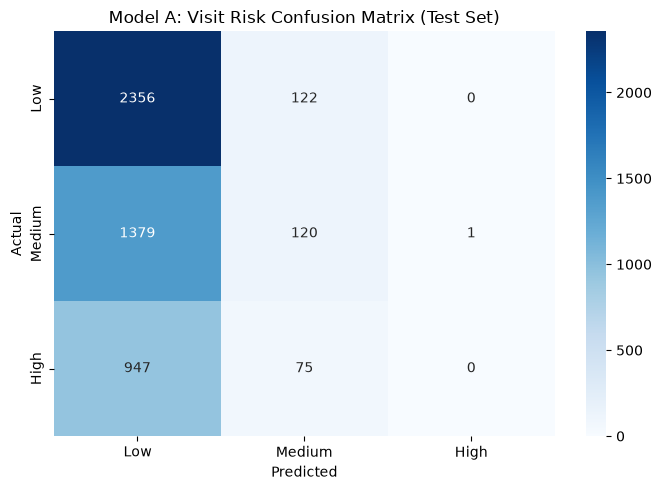

In [2]:
features_A = [
    'age', 'gender', 'city', 'chronic_flag', 
    'length_of_stay_hours', 'department', 'visit_type',
    'days_since_registration', 'visit_month', 'visit_day_of_week',
    'visit_frequency', 'avg_length_of_stay_patient'
]

# Train predictions
train_preds_A = model_A.predict(train_df[features_A])
test_preds_A = model_A.predict(test_df[features_A])

print("=== MODEL A: VISIT RISK CLASSIFICATION (TEST SET) ===")
print(classification_report(test_df['risk_score_encoded'], test_preds_A, target_names=['Low', 'Medium', 'High']))

# Confusion Matrix
cm_A = confusion_matrix(test_df['risk_score_encoded'], test_preds_A)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Model A: Visit Risk Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("../plots/model_A_confusion_matrix.png", dpi=300)
plt.show()

## 2. Technical Evaluation (Model B: Claim Outcome Classification)
We evaluate Model B on train and test sets, generating confusion matrices and classification reports.

D:\Projects\IITM\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


D:\Projects\IITM\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== MODEL B: CLAIM OUTCOME CLASSIFICATION (TEST SET) ===
              precision    recall  f1-score   support

        Paid       0.67      0.44      0.53      2994
     Pending       0.28      0.19      0.23      1276
    Rejected       0.22      0.66      0.34       730

    accuracy                           0.41      5000
   macro avg       0.39      0.43      0.37      5000
weighted avg       0.51      0.41      0.43      5000



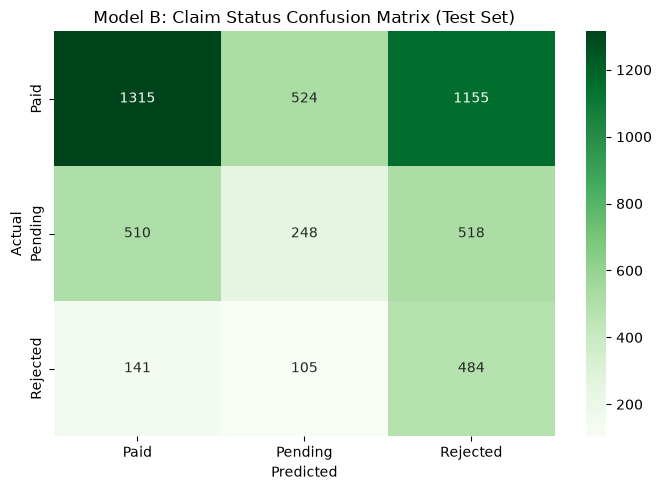

In [3]:
features_B = [
    'age', 'gender', 'city', 'chronic_flag', 
    'length_of_stay_hours', 'department', 'visit_type',
    'days_since_registration', 'visit_month', 'visit_day_of_week',
    'visit_frequency', 'avg_length_of_stay_patient',
    'risk_score', 'billed_amount', 'insurance_provider', 
    'provider_rejection_rate', 'revenue_realization_rate_dept'
]

# Test predictions
train_preds_B = model_B.predict(train_df[features_B])
test_preds_B = model_B.predict(test_df[features_B])

print("=== MODEL B: CLAIM OUTCOME CLASSIFICATION (TEST SET) ===")
print(classification_report(test_df['claim_status_encoded'], test_preds_B, target_names=['Paid', 'Pending', 'Rejected']))

# Confusion Matrix
cm_B = confusion_matrix(test_df['claim_status_encoded'], test_preds_B)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', xticklabels=['Paid', 'Pending', 'Rejected'], yticklabels=['Paid', 'Pending', 'Rejected'])
plt.title('Model B: Claim Status Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("../plots/model_B_confusion_matrix.png", dpi=300)
plt.show()

## 3. Business Metrics and Financial ROI
We translate standard classification metrics into hospital business impact metrics:
1. **High-Risk Recall:** Measures the percentage of High-Risk encounters correctly predicted, helping clinicial teams allocate ICU beds and mitigate operational bottlenecks.
2. **Rejected Claim Recall:** Measures the percentage of rejections successfully flagged *before* submission, allowing the finance team to correct billing errors and secure revenue realization.
3. **Estimated Revenue Protection:** We calculate the total billed amount of rejected claims that our model successfully flagged.

In [4]:
# 1. High Risk Visit Recall
cm_A_norm = cm_A.astype('float') / cm_A.sum(axis=1)[:, np.newaxis]
high_risk_recall = cm_A_norm[2, 2]
print(f"Clinical Impact: High-Risk Visit Recall = {high_risk_recall * 100:.2f}%")

# 2. Rejected Claim Recall
cm_B_norm = cm_B.astype('float') / cm_B.sum(axis=1)[:, np.newaxis]
rejected_claim_recall = cm_B_norm[2, 2]
print(f"Financial Impact: Rejected Claim Recall = {rejected_claim_recall * 100:.2f}%")

# 3. Revenue Protection Estimation
# Sum of billed amounts for claims in test set that were Rejected and predicted as Rejected
actual_rejected_mask = test_df['claim_status_encoded'] == 2
pred_rejected_mask = test_preds_B == 2
correctly_flagged_rejections = test_df[actual_rejected_mask & pred_rejected_mask]
total_rejected_billed = test_df[actual_rejected_mask]['billed_amount'].sum()
flagged_rejected_billed = correctly_flagged_rejections['billed_amount'].sum()

print(f"Total Billed Amount under Rejected Claims in Test Set: INR {total_rejected_billed:,.2f}")
print(f"Potential Leakage Flagged/Prevented by Model: INR {flagged_rejected_billed:,.2f} ({flagged_rejected_billed * 100 / total_rejected_billed:.2f}% of rejections caught)")

Clinical Impact: High-Risk Visit Recall = 0.00%
Financial Impact: Rejected Claim Recall = 66.30%
Total Billed Amount under Rejected Claims in Test Set: INR 14,406,488.06
Potential Leakage Flagged/Prevented by Model: INR 9,645,343.83 (66.95% of rejections caught)


## 4. Explainability & Feature Importance
We extract the feature importances from our trained models. Since our models are wrapped in Pipelines, we extract the feature names out of the OneHotEncoder to align importances with their corresponding categorical columns.

In [5]:
def get_feature_importances(pipeline, numerical_features, categorical_features):
    # Get encoder
    preprocessor = pipeline.named_steps['preprocessor']
    ohe = preprocessor.named_transformers_['cat']
    cat_encoded = ohe.get_feature_names_out(categorical_features)
    all_features = numerical_features + list(cat_encoded)
    
    # Get classifier importances
    classifier = pipeline.named_steps['classifier']
    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
    else:
        importances = np.abs(classifier.coef_[0])  # fallback for linear models
        
    feat_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    return feat_df

num_features_A = ['age', 'length_of_stay_hours', 'days_since_registration', 'visit_month', 'visit_day_of_week', 'visit_frequency', 'avg_length_of_stay_patient']
cat_features_A = ['gender', 'city', 'department', 'visit_type']
feat_A = get_feature_importances(model_A, num_features_A, cat_features_A)
print("--- Model A: Visit Risk Feature Importances (Top 10) ---")
print(feat_A.head(10))

num_features_B = ['age', 'length_of_stay_hours', 'days_since_registration', 'visit_month', 'visit_day_of_week', 'visit_frequency', 'avg_length_of_stay_patient', 'billed_amount', 'provider_rejection_rate', 'revenue_realization_rate_dept']
cat_features_B = ['gender', 'city', 'department', 'visit_type', 'risk_score', 'insurance_provider']
feat_B = get_feature_importances(model_B, num_features_B, cat_features_B)
print("\n--- Model B: Claim Status Feature Importances (Top 10) ---")
print(feat_B.head(10))

--- Model A: Visit Risk Feature Importances (Top 10) ---
                       Feature  Importance
1         length_of_stay_hours    0.202244
6   avg_length_of_stay_patient    0.147455
0                          age    0.116087
2      days_since_registration    0.091058
5              visit_frequency    0.072486
3                  visit_month    0.071785
4            visit_day_of_week    0.063548
22              visit_type_ICU    0.016969
8                     gender_M    0.016579
21               visit_type_ER    0.016309

--- Model B: Claim Status Feature Importances (Top 10) ---
                         Feature  Importance
7                  billed_amount         990
0                            age         579
1           length_of_stay_hours         558
6     avg_length_of_stay_patient         543
2        days_since_registration         389
3                    visit_month         214
5                visit_frequency         168
4              visit_day_of_week         147
9  re

C:\Users\yuvar\AppData\Local\Temp\ipykernel_24360\819142883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_A.head(10), ax=axes[0], palette='Blues_r')
C:\Users\yuvar\AppData\Local\Temp\ipykernel_24360\819142883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_B.head(10), ax=axes[1], palette='Greens_r')


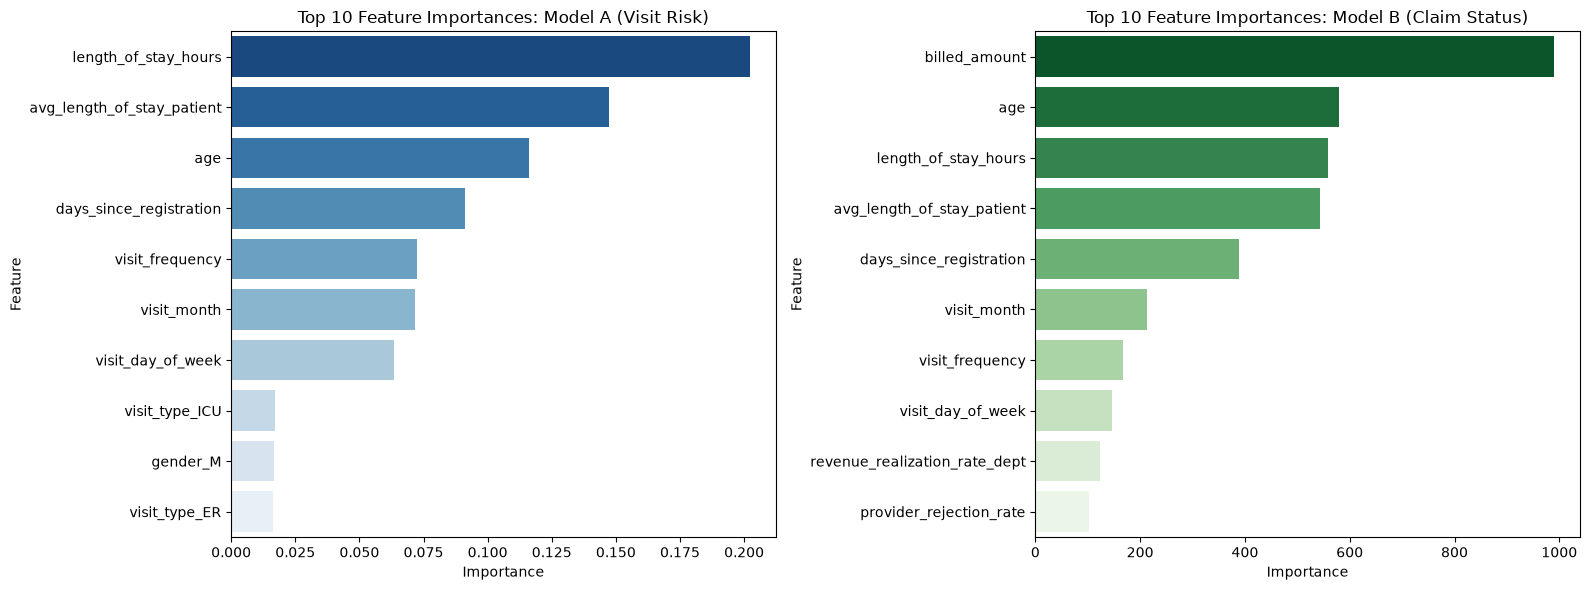

In [6]:
# Plot top feature importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Importance', y='Feature', data=feat_A.head(10), ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Feature Importances: Model A (Visit Risk)')

sns.barplot(x='Importance', y='Feature', data=feat_B.head(10), ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Feature Importances: Model B (Claim Status)')

plt.tight_layout()
plt.savefig("../plots/model_feature_importances.png", dpi=300)
plt.show()

## 5. Fairness & Model Bias Analysis
We segment Model B claim outcome predictions across patient demographics (`gender`, `city`) and `insurance_provider` to verify that the model doesn't exhibit bias.

In [7]:
def analyze_fairness(df, preds, segment_col, true_col):
    df = df.copy()
    df['pred'] = preds
    
    results = []
    for group, group_df in df.groupby(segment_col):
        acc = accuracy_score(group_df[true_col], group_df['pred'])
        f1 = f1_score(group_df[true_col], group_df['pred'], average='weighted')
        # Calculate recall for Rejected class (encoded as 2)
        y_true_g = group_df[true_col]
        y_pred_g = group_df['pred']
        rejected_mask = y_true_g == 2
        rej_recall = accuracy_score(y_true_g[rejected_mask], y_pred_g[rejected_mask]) if rejected_mask.sum() > 0 else np.nan
        
        results.append({
            'Segment': group,
            'Volume': len(group_df),
            'Accuracy': acc,
            'Weighted F1': f1,
            'Rejected Recall': rej_recall
        })
    return pd.DataFrame(results)

print("=== Model B: Fairness Analysis by Gender ===")
print(analyze_fairness(test_df, test_preds_B, 'gender', 'claim_status_encoded'))

print("\n=== Model B: Fairness Analysis by City ===")
print(analyze_fairness(test_df, test_preds_B, 'city', 'claim_status_encoded'))

print("\n=== Model B: Fairness Analysis by Insurance Provider ===")
print(analyze_fairness(test_df, test_preds_B, 'insurance_provider', 'claim_status_encoded'))

=== Model B: Fairness Analysis by Gender ===
  Segment  Volume  Accuracy  Weighted F1  Rejected Recall
0       F    2529  0.413207     0.424684         0.664975
1       M    2471  0.405504     0.425687         0.660714

=== Model B: Fairness Analysis by City ===
     Segment  Volume  Accuracy  Weighted F1  Rejected Recall
0  Bangalore     829  0.402895     0.423372         0.624000
1    Chennai     825  0.420606     0.429227         0.694030
2      Delhi     849  0.399293     0.426547         0.679245
3  Hyderabad     892  0.418161     0.426236         0.631944
4     Mumbai     818  0.431540     0.441287         0.661417
5       Pune     787  0.382465     0.399989         0.702128

=== Model B: Fairness Analysis by Insurance Provider ===
      Segment  Volume  Accuracy  Weighted F1  Rejected Recall
0     CareOne    1237  0.417947     0.432397         0.675978
1  HealthPlus    1199  0.392827     0.407094         0.672414
2   MediCareX    1365  0.402930     0.417279         0.634518
3  S